In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split
import numpy as np

In [3]:
def create_complex_dataset(n_samples = 1200):
    X = torch.randn(n_samples, 20) # 1200개 샘플, 특징 20개의 램덤 데이터
    y = (torch.sin(X[:, 0] * 2) + X[:,1]**2 - torch.abs(X[:,2]) + torch.randn(n_samples)*0.1).reshape(-1, 1)
    y = (y - y.mean()) / y.std()
    return TensorDataset(X, y)

In [4]:
dataset = create_complex_dataset()
train_size = int(0.8 * len(dataset)) # 960개
val_size = len(dataset) - train_size # 240개
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, drop_last=True) 
# train_loader에 객체로 어떻게 꺼낼지에 대한 설정이 담겨있음 (값 아님)
val_loader = DataLoader(val_dataset, batch_size=32, drop_last=True) # 평가용이라 셔플 필요 X


In [5]:
x_batch, y_batch = next(iter(train_loader))
x_batch.shape, y_batch.shape
# DataLoader가 제대로 작동하는지 확인용 셀

(torch.Size([32, 20]), torch.Size([32, 1]))

In [6]:
class EarlyStopping:
    def __init__(self, patience=7, min_delta=0, path='best_model.pt'):
        self.patience = patience # 몇 번까지 참을지 (7번 연속 개선 X면 중지)
        self.min_delta = min_delta 
        # 이 값보다 작게 줄어들면 개선으로 보지 않음, 기본값이 0이면 조금이라도 줄면 개선
        self.path = path
        self.best_loss = float('inf')
        # 처음에 비교 기준 없음니 무한대로 설정, 첫 번째 val_loss가 무저건 "개선됨"으로 인식
        self.early_stop = False
        # True가 되면 학습 중단 신호
        self.counter = 0

    def __call__(self, val_loss, model): # 인스턴스를 함수처럼 호출 할 수 있게 해줌
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss = val_loss
            self.counter = 0
            torch.save(model.state_dict(), self.path)
            print(f"validation loss find {self.best_loss:.6f} model saved")
        else:
            self.counter += 1
            print(f"EarlyStopping counter : {self.counter}")
            if self.counter >= self.patience:
                self.early_stop = True

In [7]:
class AdvancedModel(nn.Module):
    def __init__(self, input_dim, dropout_p=0.3):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)

model = AdvancedModel(input_dim=20)
print(model)

AdvancedModel(
  (network): Sequential(
    (0): Linear(in_features=20, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [8]:
from tqdm import tqdm
optimizer = optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()
early_stopping = EarlyStopping(patience=5)

In [9]:
epochs = 200
train_loss = []; val_loss = []
pbar = tqdm(range(epochs))

for epoch in pbar:
    batch_train_losses = 0.0; batch_val_losses=0.0

    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        output = model(batch_x)
        loss = criterion(output, batch_y)
        loss.backward()
        optimizer.step()
        batch_train_losses += loss.item()

    train_loss.append(batch_train_losses / len(train_loader))

    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            output = model(batch_x)
            loss = criterion(output, batch_y)
            batch_val_losses += loss.item()

        val_loss.append(batch_val_losses / len(val_loader))

    pbar.set_postfix({'Train': f'{train_loss[-1]:.4f} val loss : {val_loss[-1]:.4f}'})

    if (epoch+1) % 40 == 0 or epoch == 0:
        tqdm.write(f' epoch {epoch+1} / {epochs} train loss : {train_loss[-1]:.4f} val loss : {val_loss[-1]:.4f} ')

  3%|▎         | 6/200 [00:00<00:06, 27.98it/s, Train=0.1530 val loss : 0.2368]

 epoch 1 / 200 train loss : 1.0441 val loss : 0.7630 


 22%|██▎       | 45/200 [00:01<00:05, 26.89it/s, Train=0.0025 val loss : 0.2440]

 epoch 40 / 200 train loss : 0.0023 val loss : 0.2428 


 42%|████▏     | 84/200 [00:03<00:04, 26.69it/s, Train=0.0011 val loss : 0.2394]

...

 epoch 120 / 200 train loss : 0.0027 val loss : 0.2334 


 81%|████████  | 162/200 [00:06<00:01, 24.15it/s, Train=0.0056 val loss : 0.2231]

 epoch 160 / 200 train loss : 0.0030 val loss : 0.2247 


100%|██████████| 200/200 [00:07<00:00, 25.92it/s, Train=0.0022 val loss : 0.2186]

 epoch 200 / 200 train loss : 0.0022 val loss : 0.2186 


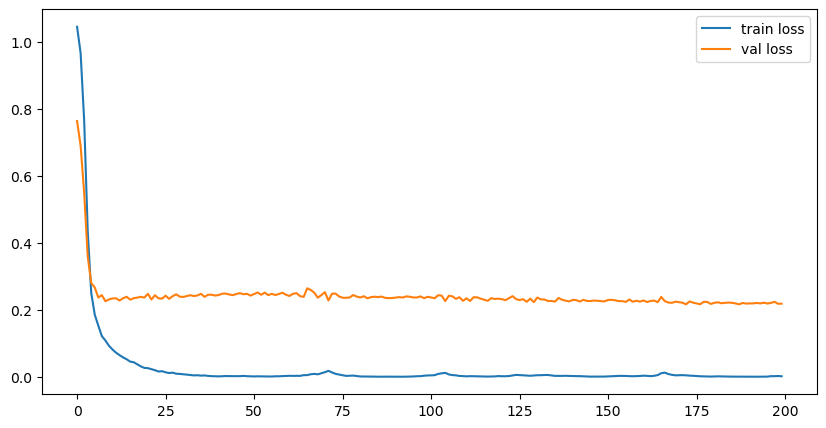

In [10]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10,5))
plt.plot(range(epochs), train_loss, label = 'train loss')
plt.plot(range(epochs), val_loss, label='val loss')
plt.legend()
plt.show()

In [9]:
class AdvancedModel(nn.Module):
    def __init__(self, input_dim, dropout_p=0.3):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),

            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64, 32),
            nn.ReLU(),

            nn.Linear(32, 1),
        )

    def forward(self, x):
        return self.network(x)
    
model = AdvancedModel(input_dim=20)
print(model)

AdvancedModel(
  (network): Sequential(
    (0): Linear(in_features=20, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): ReLU()
    (6): Linear(in_features=32, out_features=1, bias=True)
  )
)


In [10]:
new_layers = []
model = AdvancedModel(input_dim=20)
for i, layer in enumerate(list(model.network)):
    new_layers.append(layer)
    if isinstance(layer, nn.Linear) and i < len(list(model.network))-1:
        new_layers.append(nn.BatchNorm1d(layer.out_features))
    elif isinstance(layer, nn.ReLU):
        new_layers.append(nn.Dropout(0.3))

new_model = nn.Sequential(*new_layers)
new_model
    

Sequential(
  (0): Linear(in_features=20, out_features=128, bias=True)
  (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU()
  (3): Dropout(p=0.3, inplace=False)
  (4): Linear(in_features=128, out_features=64, bias=True)
  (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (6): ReLU()
  (7): Dropout(p=0.3, inplace=False)
  (8): Linear(in_features=64, out_features=32, bias=True)
  (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (10): ReLU()
  (11): Dropout(p=0.3, inplace=False)
  (12): Linear(in_features=32, out_features=1, bias=True)
)

In [13]:
from tqdm import tqdm
optimizer = optim.Adam(new_model.parameters(), lr=1e-3)
criterion = nn.MSELoss()
early_stopping = EarlyStopping(patience=5)

epochs = 200
train_loss=[]; val_loss=[]
pbar = tqdm(range(epochs))
for epoch in pbar:
    new_model.train() # 드랍아웃과 배치 정규화가 학습 및 평가할 때 서로 다르게 동작하는걸 방지
    batch_train_losses = 0.0; batch_val_losses = 0.0

    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        output = new_model(batch_x)
        loss = criterion(output, batch_y)
        loss.backward()
        optimizer.step()
        batch_train_losses += loss.item()
    train_loss.append(batch_train_losses / len(train_loader))

    new_model.eval()
    with torch.no_grad():
        for batch_x, batch_y in val_loader:
            output = new_model(batch_x)
            loss = criterion(output, batch_y)
            batch_val_losses += loss.item()
        val_loss.append(batch_val_losses / len(val_loader))

    pbar.set_postfix({'Train': f'{train_loss[-1]:.4f}', 'val': f'{val_loss[-1]:.4f}'})

    if (epoch+1) % 40 == 0 or epoch == 0:
        tqdm.write(f'epoch {epoch+1} / {epochs} train loss : {train_loss[-1]:.4f} val loss : {val_loss[-1]:.4f}')
        



  1%|          | 2/200 [00:00<00:12, 15.56it/s, Train=1.0347, val=0.7448]

epoch 1 / 200 train loss : 1.2664 val loss : 0.8072


 21%|██        | 42/200 [00:02<00:10, 15.63it/s, Train=0.3766, val=0.2013]

epoch 40 / 200 train loss : 0.3791 val loss : 0.2158


 41%|████      | 82/200 [00:05<00:07, 15.79it/s, Train=0.2921, val=0.1544]

...

epoch 120 / 200 train loss : 0.2189 val loss : 0.1196


 81%|████████  | 162/200 [00:10<00:02, 15.04it/s, Train=0.2483, val=0.1123]

epoch 160 / 200 train loss : 0.2343 val loss : 0.1016


100%|██████████| 200/200 [00:13<00:00, 15.04it/s, Train=0.2191, val=0.1041]

epoch 200 / 200 train loss : 0.2191 val loss : 0.1041


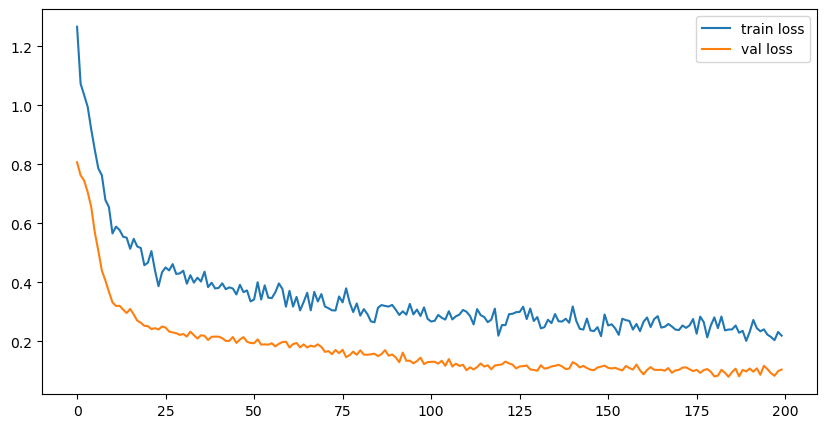

In [14]:
fig, ax = plt.subplots(figsize=(10, 5))
plt.plot(range(epochs), train_loss, label='train loss')
plt.plot(range(epochs), val_loss, label='val loss')
plt.legend()
plt.show()

In [11]:
from tqdm import tqdm
optimizer = optim.Adam(new_model.parameters(), lr=1e-3)
criterion = nn.MSELoss()
early_stopping = EarlyStopping(patience=7)

epochs = 2000
train_loss = []; val_loss = []
pbar = tqdm(range(epochs))

best_epoch = 0
for epoch in pbar:
    new_model.train() # 이거 아직 이해 잘 안됨
    batch_train_losses = 0.0; batch_val_losses = 0.0

    for batch_x, batch_y in train_loader:
        optimizer.zero_grad()
        output = new_model(batch_x)
        loss = criterion(output, batch_y)
        loss.backward()
        optimizer.step()
        batch_train_losses += loss.item() # 정확히 어떤 값이 들어감?

    new_model.eval()
    with torch.no_grad():
        for batch_val_x, batch_val_y in val_loader:
            output = new_model(batch_val_x)
            loss = criterion(output, batch_val_y)
            batch_val_losses += loss.item()

    train_loss.append(batch_train_losses / len(train_loader))
    val_loss.append(batch_val_losses / len(val_loader))
    pbar.set_postfix({'Train': f'{train_loss[-1]:.4f}', 'val': f'{val_loss[-1]:.4f}'})

    if (epoch+1) % 20 == 0 or epoch == 0:
        tqdm.write(f'epoch {epoch+1} / {epochs} train loss : {train_loss[-1]:.4f}  val loss : {val_loss[-1]:.4f}')


    early_stopping(val_loss[-1], new_model)
    if early_stopping.early_stop:
        print(f'early stopping train loss : {train_loss[-1]:.4f} val loss : {val_loss[-1]:.4f}')
        best_epoch = epoch
        break


  0%|          | 4/2000 [00:00<02:17, 14.54it/s, Train=0.9117, val=0.8898]

epoch 1 / 2000 train loss : 1.2374  val loss : 0.9988
validation loss find 0.998805 model saved
validation loss find 0.978860 model saved
validation loss find 0.941961 model saved
validation loss find 0.889838 model saved


  0%|          | 8/2000 [00:00<02:06, 15.75it/s, Train=0.6484, val=0.5503]

validation loss find 0.813810 model saved
validation loss find 0.752111 model saved
validation loss find 0.652139 model saved
validation loss find 0.550347 model saved


  1%|          | 12/2000 [00:00<02:05, 15.86it/s, Train=0.5053, val=0.4224]

...

EarlyStopping counter : 1
EarlyStopping counter : 2
validation loss find 0.298487 model saved
validation loss find 0.272036 model saved


  2%|▏         | 36/2000 [00:02<02:09, 15.19it/s, Train=0.3704, val=0.2881]

EarlyStopping counter : 1
EarlyStopping counter : 2
EarlyStopping counter : 3
EarlyStopping counter : 4


  2%|▏         | 38/2000 [00:02<02:11, 14.87it/s, Train=0.3656, val=0.2898]

EarlyStopping counter : 5
EarlyStopping counter : 6
EarlyStopping counter : 7
early stopping train loss : 0.3656 val loss : 0.2898


In [12]:
len(train_loss), best_epoch

(39, 38)

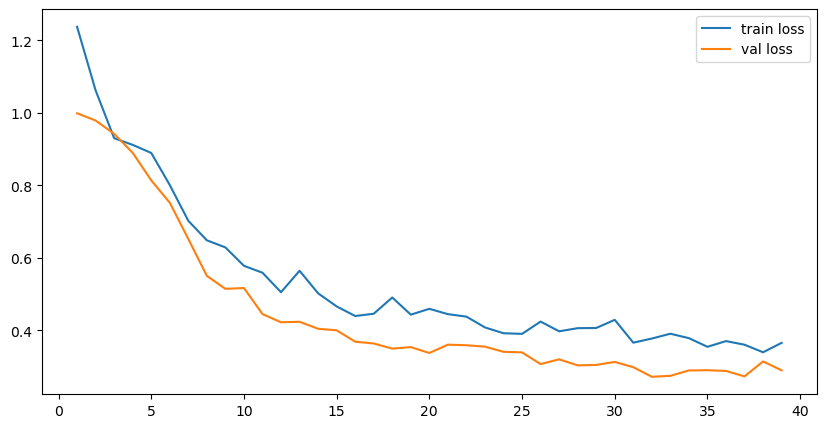

In [14]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(10, 5))
plt.plot(range(1, best_epoch+2), train_loss, label='train loss')
plt.plot(range(1, best_epoch+2), val_loss, label='val loss')
plt.legend()
plt.show()